## Data investigation

In [1]:
!pip install mlflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
import mlflow
from sklearn.preprocessing import LabelEncoder
from sklearn import datasets, model_selection, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

In [3]:
df = pd.read_csv("Cars.csv")
print(df.info())
pd.set_option("display.max_columns", None)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB
None


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## Data transformation and data type changes


In [4]:
#For floats to look pretty
pd.options.display.float_format = '{:g}'.format

In [5]:
#Remain only the name of the brand of the car, and change the name of the column to brand
df["brand"] = df["name"].str.split().str[0]
df.drop(columns=["name"], inplace=True)

In [6]:
#Fuel remove
df = df[df["fuel"] != "CNG"]
df = df[df["fuel"] != "LPG"]

In [7]:
#Owner replace with numbers
df["owner"] = df["owner"].map({"First Owner": 1, "Second Owner": 2, "Third Owner": 3,
    "Fourth & Above Owner": 4,"Test Drive Car":5})

In [8]:
#Drop entities where owner was "Test Drive Cars"
df = df[df["owner"] != 5]

In [9]:
#Dropping down the units and changing data type for mileage
df["mileage"] = df["mileage"].str.split().str[0]
df["mileage"] = df["mileage"].astype(float)

In [10]:
#Engine dropping CC and changing the data type
df["engine"] = df["engine"].str.split().str[0]
df["engine"] = df["engine"].astype("Int64")

In [11]:
#max_power dropping CC and data typpe change + if there was not a value befor bhp change to nan
df["max_power"] = df["max_power"].str.split().str[0]
df["max_power"] = df["max_power"].replace("bhp", np.nan)
df["max_power"] = df["max_power"].astype(float)

In [12]:
#Dropping torque column
df.drop(columns=["torque"], inplace=True)

In [13]:
#Keeping the order as in the instruction for clairty
df = df[["brand",  "year", "selling_price", "km_driven", "fuel", "seller_type",
        "transmission", "owner", "mileage", "engine", "max_power", "seats"]]

In [14]:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.4,1248,74,5
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.7,1497,78,5
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23,1396,90,5
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.1,1298,88.2,5


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8028 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          8028 non-null   object 
 1   year           8028 non-null   int64  
 2   selling_price  8028 non-null   int64  
 3   km_driven      8028 non-null   int64  
 4   fuel           8028 non-null   object 
 5   seller_type    8028 non-null   object 
 6   transmission   8028 non-null   object 
 7   owner          8028 non-null   int64  
 8   mileage        7814 non-null   float64
 9   engine         7814 non-null   Int64  
 10  max_power      7820 non-null   float64
 11  seats          7814 non-null   float64
dtypes: Int64(1), float64(3), int64(4), object(4)
memory usage: 823.2+ KB
None


## EDA

In [16]:
df.columns

Index(['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='object')

### Univariate analyis

<Axes: xlabel='fuel', ylabel='count'>

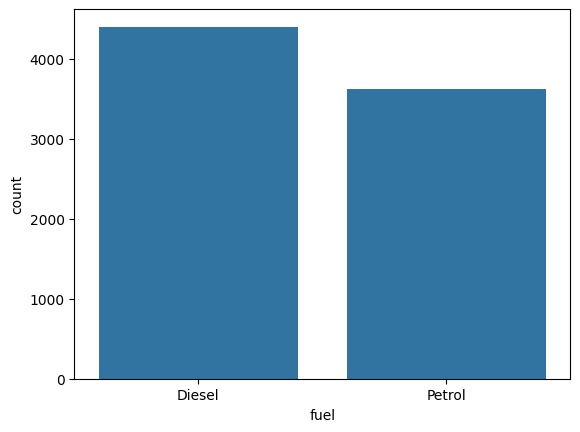

In [17]:
sns.countplot(x="fuel", data=df)

Daset contains more cars that consume diesel

<Axes: xlabel='seller_type', ylabel='count'>

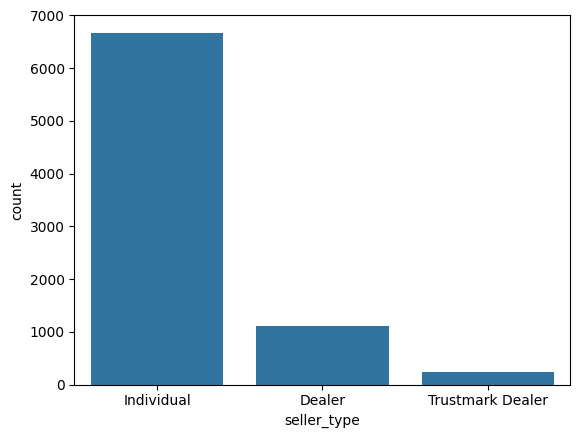

In [18]:
sns.countplot(x="seller_type", data=df)

The biggest selling group are individual sellers, the smallest trustmerk dealers

<Axes: xlabel='transmission', ylabel='count'>

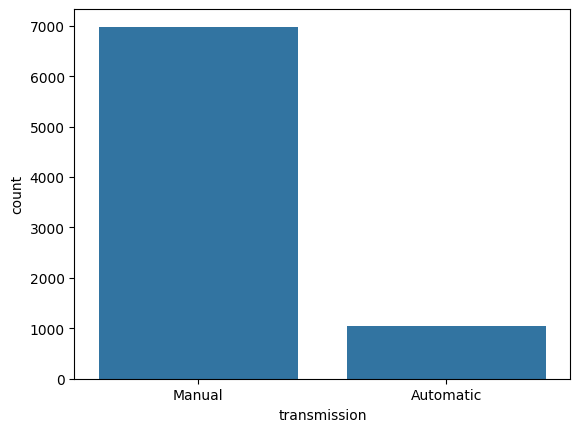

In [19]:
sns.countplot(x="transmission", data=df)

The majority of the cars in the database are the ones with manual transmission

<Axes: xlabel='owner', ylabel='count'>

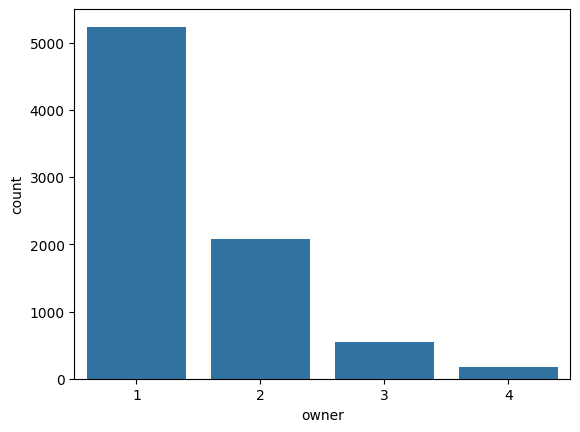

In [20]:
sns.countplot(x="owner", data=df)

The dataset consists mostly of cars with one previous owner, with the number of cars decreasing as the number of previous owners increases

<Axes: xlabel='selling_price', ylabel='Count'>

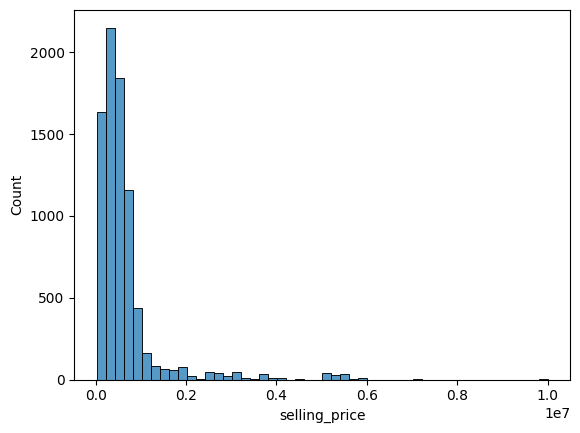

In [21]:
sns.histplot(df["selling_price"], bins=50)

Selling prices are skewed to the left

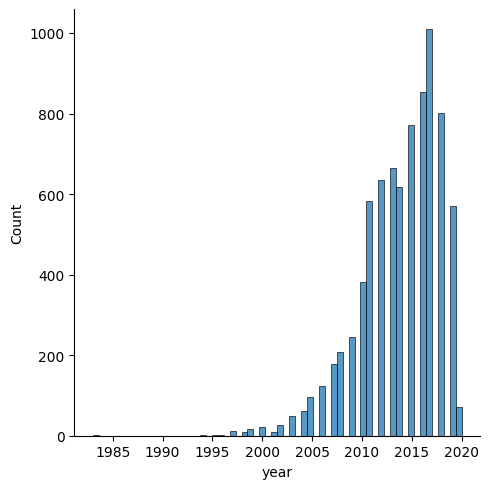

In [22]:
sns.displot(df["year"])

Year of production plot is skewed to the right

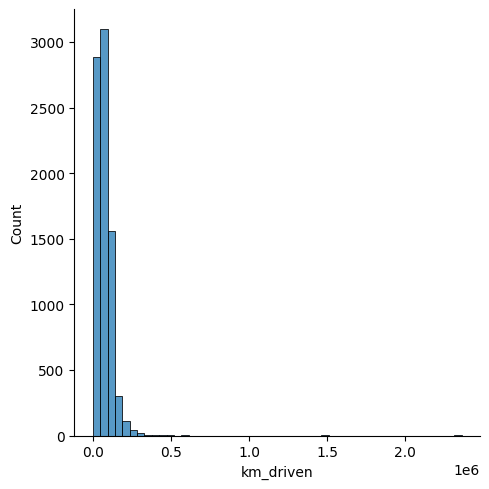

In [23]:
sns.displot(df["km_driven"], bins=50)

Most cars have low amount of kilometers driven

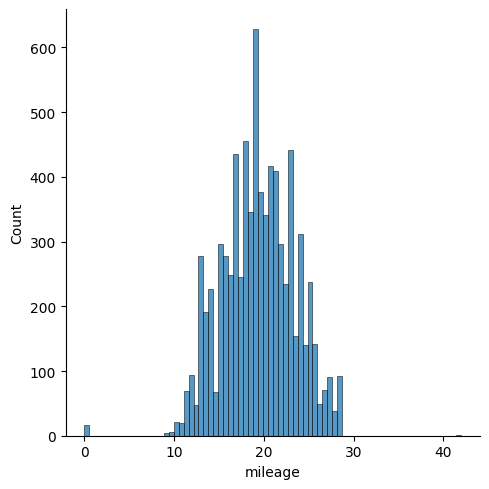

In [24]:
sns.displot(df["mileage"])

Mileage has normal distribution

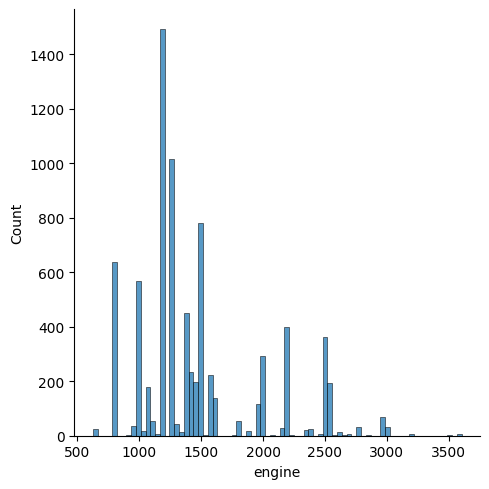

In [25]:
sns.displot(df["engine"])

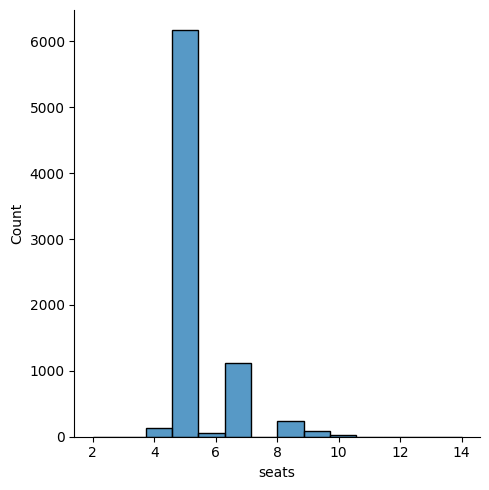

In [26]:
sns.displot(df["seats"])

Majority of the cars in the database has 5 seats, the smallest seats number is 4, and the biggest is 11

### Multivariate analysis

<Axes: xlabel='year', ylabel='selling_price'>

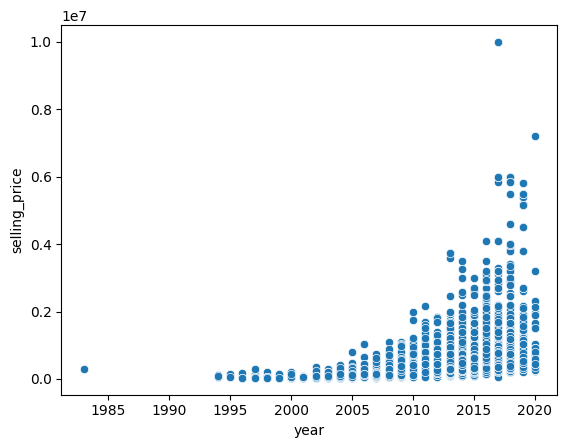

In [27]:
sns.scatterplot(x="year", y="selling_price", data=df)

Younger the car higher the price, with two outliers spots in ~2018 and ~2020

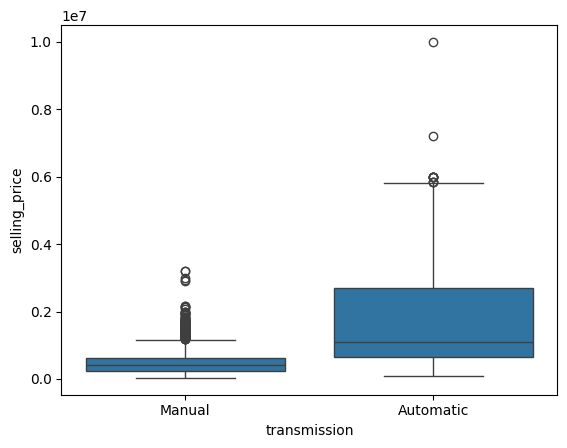

In [28]:
sns.boxplot(x="transmission", y="selling_price", data=df)
plt.show()

Automatic cars are pricier than the ones with manual transmission

### Correlation Matrix

In [29]:
df.columns

Index(['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='object')

In [30]:
#Encoding the labels for columns fuel and transmission for the correlation matrix
df_corr = df.copy()
le_fuel = LabelEncoder()
df_corr["fuel"] = le_fuel.fit_transform(df_corr["fuel"])
le_fuel.classes_

array(['Diesel', 'Petrol'], dtype=object)

In [31]:
le_transmission = LabelEncoder()
df_corr["transmission"] = le_transmission.fit_transform(df_corr["transmission"])
le_transmission.classes_

array(['Automatic', 'Manual'], dtype=object)

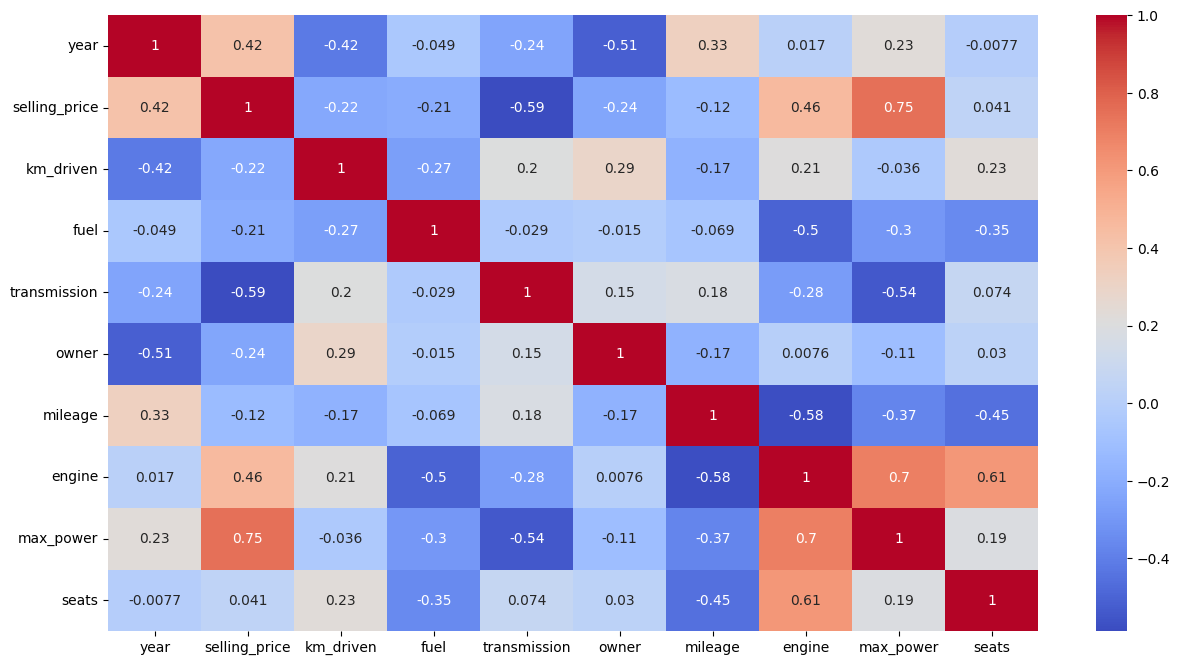

In [32]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Over all the features are not strongly correlated. Selling price is strongly correlated with max power, transmission, engine, and year.

# Preparation for interference


## Duplicates verification
 If there are any, it is necessary to take care of it, because model can be tested in already seen samples

In [33]:
df.duplicated().sum()

np.int64(1220)

In [34]:
#Manual verification if the cars are actually the same or similar
duplicates = df[df.duplicated(keep=False)]
duplicates.sort_values(by=list(df.columns))

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
2129,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5
7775,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5
1977,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5
7324,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5
131,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6558,Volvo,2019,3800000,20000,Diesel,Individual,Automatic,1,18,1969,190,5
6577,Volvo,2019,3800000,20000,Diesel,Individual,Automatic,1,18,1969,190,5
6693,Volvo,2019,3800000,20000,Diesel,Individual,Automatic,1,18,1969,190,5
6963,Volvo,2019,3800000,20000,Diesel,Individual,Automatic,1,18,1969,190,5


In [35]:
#Yes, they are the same- dropping them, and than reseting indexes
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [36]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6808 entries, 0 to 6807
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          6808 non-null   object 
 1   year           6808 non-null   int64  
 2   selling_price  6808 non-null   int64  
 3   km_driven      6808 non-null   int64  
 4   fuel           6808 non-null   object 
 5   seller_type    6808 non-null   object 
 6   transmission   6808 non-null   object 
 7   owner          6808 non-null   int64  
 8   mileage        6607 non-null   float64
 9   engine         6607 non-null   Int64  
 10  max_power      6610 non-null   float64
 11  seats          6607 non-null   float64
dtypes: Int64(1), float64(3), int64(4), object(4)
memory usage: 645.0+ KB
None


## Splitting

In [37]:
y_cut, cut_bins = pd.cut( df["selling_price"], bins=4, labels=[0, 1, 2, 3], retbins=True)
y_cut = y_cut.astype(int)

print("Class counts:")
print(y_cut.value_counts().sort_index())
print("\nPrice boundaries:")
print(cut_bins)

Class counts:
selling_price
0    6728
1      63
2      16
3       1
Name: count, dtype: int64

Price boundaries:
[   20028.999  2522499.25   5014999.5    7507499.75  10000000.   ]


As it can be seen the classes are highly imbalanced, one sample in class 3 is a very poor result. Some can expect that the model tought on this data, to be biased.To separate more equally the pd.qcut() is used which is "Quantile-based discretization function." based on the https://pandas.pydata.org/docs/reference/api/pandas.qcut.html . It is expected to obtain 4 bins with equally divided samples.

In [38]:
y, qcut_bins = pd.qcut( df["selling_price"], q=4, labels=[0, 1, 2, 3], retbins=True)
y = y.astype(int)

print("Class counts:")
print(y.value_counts().sort_index())

print("\nPrice boundaries:")
print(qcut_bins)

Class counts:
selling_price
0    1841
1    1579
2    1691
3    1697
Name: count, dtype: int64

Price boundaries:
[   29999.   250000.   409999.   640000. 10000000.]


Now this looks better. (Sorry for changes)

In [39]:
#The features
x = df.drop(columns=["selling_price"])

In [40]:
#Splitting by standard 8:2 with stratification
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, stratify=y, random_state=50)

## Imputation

For columns: "mileage", "engine", "max_power", "seats" based on the normality the mean/median imputation will be performed. The histograms function is to define the normality

<Axes: >

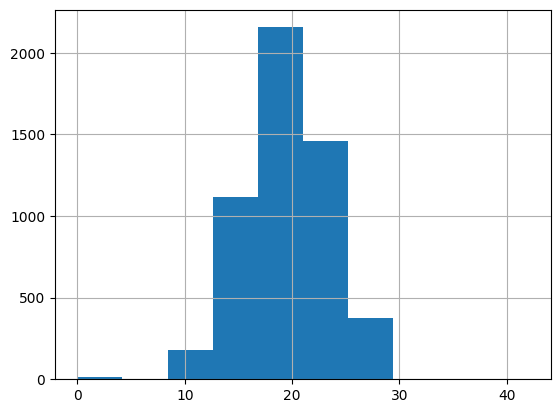

In [41]:
x_train["mileage"].hist()

<Axes: >

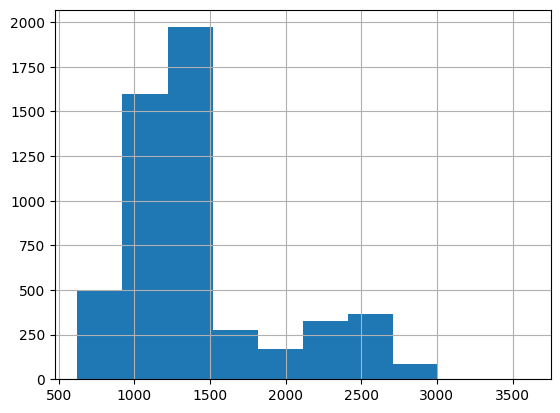

In [42]:
x_train["engine"].hist()

<Axes: >

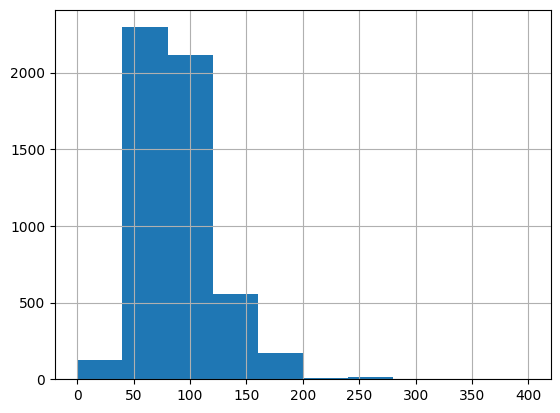

In [43]:
x_train["max_power"].hist()

<Axes: >

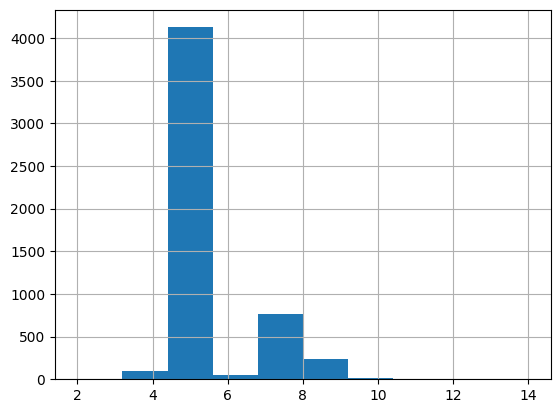

In [44]:
x_train["seats"].hist()

In [45]:
#For mileage mean is used because it has near normal distribution
mean_mileage = x_train["mileage"].mean()
x_train["mileage"] = x_train["mileage"].fillna(mean_mileage)
x_test["mileage"] = x_test["mileage"].fillna(mean_mileage)

Skewed graphs -> Median based imputations

In [46]:
median_engine = x_train["engine"].median()
x_train["engine"] = x_train["engine"].fillna(median_engine)
x_test["engine"] = x_test["engine"].fillna(median_engine)

In [47]:
median_max_power = x_train["max_power"].median()
x_train["max_power"] = x_train["max_power"].fillna(median_max_power)
x_test["max_power"] = x_test["max_power"].fillna(median_max_power)

In [48]:
#The median of the setas is rounded up to avoid partial seats
median_seats = round(x_train["seats"].median())
x_train["seats"] = x_train["seats"].fillna(median_seats)
x_test["seats"] = x_test["seats"].fillna(median_seats)

Foe non-obligatory cathegorical features, most represented- being in the greatest amount, "modes" of each fature will be used as a default value.

In [49]:
print(df.loc[x_train.index, "fuel"].value_counts())
print(df.loc[x_train.index, "seller_type"].value_counts())
print(df.loc[x_train.index, "owner"].value_counts())
mode_fuel = df.loc[x_train.index, "fuel"].mode()[0]
mode_seller_type = df.loc[x_train.index, "seller_type"].mode()[0]
mode_owner = df.loc[x_train.index, "owner"].mode()[0]

fuel
Diesel    2991
Petrol    2455
Name: count, dtype: int64
seller_type
Individual          4873
Dealer               550
Trustmark Dealer      23
Name: count, dtype: int64
owner
1    3360
2    1548
3     407
4     131
Name: count, dtype: int64


## Encoding

In [50]:
#To verify if One Hot Encoding is good way for the object columns
print(x_train["brand"].unique())
print(x_train["fuel"].unique())
print(x_train["seller_type"].unique())
print(x_train["transmission"].unique())

['Tata' 'Toyota' 'Ford' 'Chevrolet' 'Skoda' 'Hyundai' 'Maruti' 'Fiat'
 'Nissan' 'Volkswagen' 'Renault' 'Mahindra' 'Audi' 'Jeep' 'Datsun' 'Honda'
 'Mitsubishi' 'BMW' 'Mercedes-Benz' 'Volvo' 'Ambassador' 'Jaguar' 'Lexus'
 'Daewoo' 'MG' 'Isuzu' 'Peugeot' 'Opel' 'Force' 'Kia' 'Ashok' 'Land']
['Diesel' 'Petrol']
['Individual' 'Dealer' 'Trustmark Dealer']
['Manual' 'Automatic']


One-Hot Encoding will be appropriate because the number of unique values in each of these four columns is reasonable

In [51]:
x_train = pd.get_dummies(x_train, columns=["brand"])
x_test = pd.get_dummies(x_test, columns=["brand"])

In [52]:
x_train = pd.get_dummies(x_train, columns=["fuel"])
x_test = pd.get_dummies(x_test, columns=["fuel"])

In [53]:
x_train = pd.get_dummies(x_train, columns=["seller_type"])
x_test = pd.get_dummies(x_test, columns=["seller_type"])

In [54]:
x_train = pd.get_dummies(x_train, columns=["transmission"])
x_test = pd.get_dummies(x_test, columns=["transmission"])

In [55]:
#If columns are in the train, they also have to be present in the test, even in the case when none of the samples has this feature
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

## Scalling

Skaling allows to diminish the differences of ranges between features. Scalling is used for the numerical features-> not the ones that were encoded in previous section, plus owner column was excluded because number is actual ordered cathegory

In [56]:
scaler_year = StandardScaler()
x_train["year"] = scaler_year.fit_transform(x_train[["year"]])
x_test["year"] = scaler_year.transform(x_test[["year"]])

In [57]:
scaler_km = StandardScaler()
x_train["km_driven"] = scaler_km.fit_transform(x_train[["km_driven"]])
x_test["km_driven"] = scaler_km.transform(x_test[["km_driven"]])

In [58]:
scaler_mileage = StandardScaler()
x_train["mileage"] = scaler_mileage.fit_transform(x_train[["mileage"]])
x_test["mileage"] = scaler_mileage.transform(x_test[["mileage"]])

In [59]:
scaler_engine = StandardScaler()
x_train["engine"] = scaler_engine.fit_transform(x_train[["engine"]])
x_test["engine"] = scaler_engine.transform(x_test[["engine"]])

In [60]:
scaler_power = StandardScaler()
x_train["max_power"] = scaler_power.fit_transform(x_train[["max_power"]])
x_test["max_power"] = scaler_power.transform(x_test[["max_power"]])

In [61]:
scaler_seats = StandardScaler()
x_train["seats"] = scaler_seats.fit_transform(x_train[["seats"]])
x_test["seats"] = scaler_seats.transform(x_test[["seats"]])

# Multinomial logistic regression- preparation



In [62]:
#Converting to numpy arrays with intercept
X_train = x_train.to_numpy(dtype=float)
X_test = x_test.to_numpy(dtype=float)

intercept = np.ones((X_train.shape[0], 1))
X_train = np.concatenate((intercept, X_train), axis=1)
intercept = np.ones((X_test.shape[0], 1))
X_test = np.concatenate((intercept, X_test), axis=1)

In [63]:
#One-hot encoded matrix
k = len(np.unique(y_train))
m = X_train.shape[0]
n = X_train.shape[1]
Y_train_encoded = np.zeros((m, k))

for each_class in range(k):
    cond = y_train.to_numpy() == each_class
    Y_train_encoded[np.where(cond), each_class] = 1

# Multinomial logistic regression

In [64]:
class NormalPenalty:
    def __call__(self, theta):
        return 0
    def derivation(self, theta):
        return 0

class RidgePenalty:
    def __init__(self, l):
        self.l = l
    def __call__(self, theta):
        return self.l * np.sum(theta[1:] ** 2)

    def derivation(self, theta):
        result = 2 * self.l * theta
        result[0] = 0
        return result

In [65]:
#All the metrics and model based on https://github.com/chaklam-silpasuwanchai/Python-for-Machine-Learning/blob/main/
class LogisticRegression:
    def __init__(self, k, n, method, alpha=0.001, max_iter=5000):
        self.k = k
        self.n = n
        self.method = method
        self.alpha = alpha
        self.max_iter = max_iter
        self.theta = np.zeros((n, k))

    def softmax(self, z):
        exp = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp / np.sum(exp, axis=1, keepdims=True)

    def loss(self, h, y):
        loss = -np.sum(y * np.log(h + 1e-10))
        loss += self.method(self.theta)
        return loss

    def gradient(self, X, h, y):
        grad = X.T @ (h - y)
        grad += self.method.derivation(self.theta)
        return grad

    def fit(self, X, y):
        for i in range(self.max_iter):
            z = X @ self.theta
            h = self.softmax(z)
            grad = self.gradient(X, h, y)
            self.theta = self.theta - self.alpha * grad
        return self

    def predict_proba(self, X):
        z = X @ self.theta
        return self.softmax(z)

    def predict(self, X):
        h = self.predict_proba(X)
        return np.argmax(h, axis=1)

    def accuracy(self, y_true, y_pred):
        correct = np.sum(y_true == y_pred)
        return correct / len(y_true)

    def precision(self, y_true, y_pred):
        precision_scores = []
        for c in range(self.k):
            TP = np.sum((y_true == c) & (y_pred == c))
            FP = np.sum((y_true != c) & (y_pred == c))
            if TP + FP == 0:
                precision = 0
            else:
                precision = TP / (TP + FP)
            precision_scores.append(precision)
        return np.array(precision_scores)

    def recall(self, y_true, y_pred):
        recall_scores = []
        for c in range(self.k):
            TP = np.sum((y_true == c) & (y_pred == c))
            FN = np.sum((y_true == c) & (y_pred != c))
            if TP + FN== 0:
                recall = 0
            else:
                recall = TP / (TP + FN)
            recall_scores.append(recall)
        return np.array(recall_scores)

    def f1(self, y_true, y_pred):
        precision_scores = self.precision(y_true, y_pred)
        recall_scores = self.recall(y_true, y_pred)
        f1_scores = []
        for c in range(self.k):
            precision = precision_scores[c]
            recall = recall_scores[c]
            if precision + recall == 0:
                f1 = 0
            else:
                f1 = 2 * precision * recall / (precision + recall)
            f1_scores.append(f1)
        return np.array(f1_scores)

    def macro_precision(self, y_true, y_pred):
        return np.mean(self.precision(y_true, y_pred))
    def macro_recall(self, y_true, y_pred):
        return np.mean(self.recall(y_true, y_pred))
    def macro_f1(self, y_true, y_pred):
        return np.mean(self.f1(y_true, y_pred))

    def support(self, y_true):
        support_scores = []
        for c in range(self.k):
            support_scores.append(np.sum(y_true == c))
        return np.array(support_scores)

    def weighted_precision(self, y_true, y_pred):
        scores = self.precision(y_true, y_pred)
        supports = self.support(y_true)
        weights = supports / len(y_true)
        return np.sum(weights * scores)

    def weighted_recall(self, y_true, y_pred):
        scores = self.recall(y_true, y_pred)
        supports = self.support(y_true)
        weights = supports / len(y_true)
        return np.sum(weights * scores)

    def weighted_f1(self, y_true, y_pred):
        scores = self.f1(y_true, y_pred)
        supports = self.support(y_true)
        weights = supports / len(y_true)
        return np.sum(weights * scores)

In [66]:
#Normal Logistic Regression - without regularization
model_normal = LogisticRegression( k=k, n=n, method=NormalPenalty(), alpha=0.0005,
    max_iter=5000)
model_normal.fit(X_train, Y_train_encoded)

In [67]:
#Prediction on the test set
y_pred_normal = model_normal.predict(X_test)
y_test_array = y_test.to_numpy()

print("Accuracy:", model_normal.accuracy(y_test_array, y_pred_normal))
print("Precision:", model_normal.precision(y_test_array, y_pred_normal))
print("Recall:", model_normal.recall(y_test_array, y_pred_normal))
print("F1:", model_normal.f1(y_test_array, y_pred_normal))
print("Macro:", model_normal.macro_precision(y_test_array, y_pred_normal),
      model_normal.macro_recall(y_test_array, y_pred_normal),
      model_normal.macro_f1(y_test_array, y_pred_normal))
print("Weighted:", model_normal.weighted_precision(y_test_array, y_pred_normal),
      model_normal.weighted_recall(y_test_array, y_pred_normal),
      model_normal.weighted_f1(y_test_array, y_pred_normal))
print("Support:", model_normal.support(y_test_array))

Accuracy: 0.6461086637298091
Precision: [0.95437262 0.47933884 0.69230769 0.68589744]
Recall: [0.68206522 0.91772152 0.05325444 0.94411765]
F1: [0.7955626  0.62975027 0.0989011  0.79455446]
Macro: 0.7029791486886199 0.649289705326823 0.5796921062099636
Weighted: 0.7121037650958727 0.646108663729809 0.5839538975818399
Support: [368 316 338 340]


In [68]:
model_ridge = LogisticRegression( k=k, n=n, method=RidgePenalty(l=0.01), alpha=0.0005,
    max_iter=5000)
model_ridge.fit(X_train, Y_train_encoded)

In [69]:
#Actual prediction
y_pred_ridge = model_ridge.predict(X_test)
print("Accuracy:", model_ridge.accuracy(y_test_array, y_pred_ridge))
print("Precision:", model_ridge.precision(y_test_array, y_pred_ridge))
print("Recall:", model_ridge.recall(y_test_array, y_pred_ridge))
print("F1:", model_ridge.f1(y_test_array, y_pred_ridge))
print("Macro:", model_ridge.macro_precision(y_test_array, y_pred_ridge),
      model_ridge.macro_recall(y_test_array, y_pred_ridge),
      model_ridge.macro_f1(y_test_array, y_pred_ridge))
print("Weighted:", model_ridge.weighted_precision(y_test_array, y_pred_ridge),
      model_ridge.weighted_recall(y_test_array, y_pred_ridge),
      model_ridge.weighted_f1(y_test_array, y_pred_ridge))
print("Support:", model_ridge.support(y_test_array))

Accuracy: 0.6461086637298091
Precision: [0.95437262 0.47933884 0.69230769 0.68589744]
Recall: [0.68206522 0.91772152 0.05325444 0.94411765]
F1: [0.7955626  0.62975027 0.0989011  0.79455446]
Macro: 0.7029791486886199 0.649289705326823 0.5796921062099636
Weighted: 0.7121037650958727 0.646108663729809 0.5839538975818399
Support: [368 316 338 340]


# Experiments + MLflow

In [70]:
import mlflow
mlflow.set_tracking_uri("sqlite:////content/mlflow_a3.db")
mlflow.set_experiment("127173-a3")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1789727295082, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789727295082, lifecycle_stage='active', name='127173-a3', tags={}, trace_location=None, workspace='default'>

In [71]:
#Regularization settings to compare
skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=50)
experiments = {
    "Normal": NormalPenalty(),
    "Ridge_0.005": RidgePenalty(l=0.005),
    "Ridge_0.05": RidgePenalty(l=0.05),
    "Ridge_0.5": RidgePenalty(l=0.5),
    "Ridge_5": RidgePenalty(l=5),
    "Ridge_50": RidgePenalty(l=50)}

In [72]:
experiment_results = []
y_train_array = y_train.to_numpy()

for name, penalty in experiments.items():
    fold_accuracies = []
    fold_macro_f1 = []
    fold_weighted_f1 = []

    with mlflow.start_run(run_name=name):
        for fold, (train_index, val_index) in enumerate(
            skf.split(X_train, y_train_array), start=1):
            #Split into folds
            X_fold_train = X_train[train_index]
            X_fold_val = X_train[val_index]
            y_fold_train = y_train_array[train_index]
            y_fold_val = y_train_array[val_index]

            Y_fold_train_encoded = np.zeros(
                (len(y_fold_train), k))

            for each_class in range(k):
                cond = y_fold_train == each_class
                Y_fold_train_encoded[np.where(cond), each_class] = 1

            #Create a new model for every fold
            if name == "Normal":
                fold_penalty = NormalPenalty()
                lambda_value = 0
            else:
                lambda_value = penalty.l
                fold_penalty = RidgePenalty(l=lambda_value)

            model = LogisticRegression( k=k, n=n, method=fold_penalty, alpha=0.0005,
                max_iter=5000)

            model.fit( X_fold_train, Y_fold_train_encoded)
            y_fold_pred = model.predict(X_fold_val)
            accuracy = model.accuracy( y_fold_val, y_fold_pred)
            macro_f1 = model.macro_f1( y_fold_val, y_fold_pred)
            weighted_f1 = model.weighted_f1( y_fold_val, y_fold_pred)

            fold_accuracies.append(accuracy)
            fold_macro_f1.append(macro_f1)
            fold_weighted_f1.append(weighted_f1)

            mlflow.log_metric("accuracy", accuracy, step=fold)
            mlflow.log_metric("macro_f1", macro_f1, step=fold)
            mlflow.log_metric("weighted_f1", weighted_f1, step=fold)

        #Average results from 5 folds
        mean_accuracy = np.mean(fold_accuracies)
        mean_macro_f1 = np.mean(fold_macro_f1)
        mean_weighted_f1 = np.mean(fold_weighted_f1)

        std_accuracy = np.std(fold_accuracies)
        std_macro_f1 = np.std(fold_macro_f1)
        std_weighted_f1 = np.std(fold_weighted_f1)

        #Log parameters
        mlflow.log_param("penalty", name)
        mlflow.log_param("lambda", lambda_value)
        mlflow.log_param("learning_rate", 0.0005)
        mlflow.log_param("max_iter", 5000)
        mlflow.log_param("cv_folds", 5)

        mlflow.log_metric("mean_accuracy", mean_accuracy)
        mlflow.log_metric("mean_macro_f1", mean_macro_f1)
        mlflow.log_metric("mean_weighted_f1", mean_weighted_f1)

        experiment_results.append({
            "Model": name,
            "Lambda": lambda_value,
            "Mean Accuracy": mean_accuracy,
            "Std Accuracy": std_accuracy,
            "Mean Macro F1": mean_macro_f1,
            "Std Macro F1": std_macro_f1,
            "Mean Weighted F1": mean_weighted_f1,
            "Std Weighted F1": std_weighted_f1
        })

        print(
            name,
            "| Accuracy:",
            round(mean_accuracy, 4),
            "| Macro F1:",
            round(mean_macro_f1, 4),
            "| Weighted F1:",
            round(mean_weighted_f1, 4)
        )

Normal | Accuracy: 0.662 | Macro F1: 0.622 | Weighted F1: 0.6259
Ridge_0.005 | Accuracy: 0.6621 | Macro F1: 0.6222 | Weighted F1: 0.6261
Ridge_0.05 | Accuracy: 0.6594 | Macro F1: 0.6172 | Weighted F1: 0.6211
Ridge_0.5 | Accuracy: 0.6359 | Macro F1: 0.5751 | Weighted F1: 0.5792
Ridge_5 | Accuracy: 0.61 | Macro F1: 0.5335 | Weighted F1: 0.5372
Ridge_50 | Accuracy: 0.5189 | Macro F1: 0.5027 | Weighted F1: 0.5015


In [73]:
#Sort from highest to lowest mean Weighted F1
results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(
    by="Mean Weighted F1", ascending=False).reset_index(drop=True)
results_df

,Model,Lambda,Mean Accuracy,Std Accuracy,Mean Macro F1,Std Macro F1,Mean Weighted F1,Std Weighted F1
0,Ridge_0.005,0.005,0.662137,0.00893528,0.622182,0.00984548,0.626057,0.00974201
1,Normal,0,0.661954,0.00924086,0.622043,0.00998478,0.625925,0.00987822
2,Ridge_0.05,0.05,0.659383,0.0101321,0.617212,0.0108855,0.621135,0.0108233
3,Ridge_0.5,0.5,0.635881,0.0104078,0.575103,0.00875961,0.579235,0.00896855
4,Ridge_5,5,0.609991,0.0136149,0.533521,0.0121689,0.537196,0.0127749
5,Ridge_50,50,0.518913,0.0176642,0.502709,0.0167512,0.501548,0.0168202


In [74]:
#Configuration with the highest mean Weighted F1 win
best_result = max(
    experiment_results,
    key=lambda result: result["Mean Weighted F1"])

best_name = best_result["Model"]
best_lambda = best_result["Lambda"]

print("Best CV model:", best_name)
print("Lambda:", best_lambda)
print("Mean CV Accuracy:", best_result["Mean Accuracy"])
print("Mean CV Macro F1:", best_result["Mean Macro F1"])
print("Mean CV Weighted F1:", best_result["Mean Weighted F1"])

if best_name == "Normal":
    best_penalty = NormalPenalty()
else:
    best_penalty = RidgePenalty(l=best_lambda)

#Train the final model using the complete training set
best_model = LogisticRegression( k=k,n=n,method=best_penalty,alpha=0.0005,max_iter=5000)
best_model.fit( X_train, Y_train_encoded)

Best CV model: Ridge_0.005
Lambda: 0.005
Mean CV Accuracy: 0.6621374714619085
Mean CV Macro F1: 0.6221821523107658
Mean CV Weighted F1: 0.6260567573227792


In [75]:
#Prediction using the final model
y_pred = best_model.predict(X_test)
print("Accuracy:", best_model.accuracy(y_test_array, y_pred))
print("Precision:", best_model.precision(y_test_array, y_pred))
print("Recall:", best_model.recall(y_test_array, y_pred))
print("F1:", best_model.f1(y_test_array, y_pred))
print("Macro Precision:", best_model.macro_precision(y_test_array, y_pred))
print("Macro Recall:", best_model.macro_recall(y_test_array, y_pred))
print("Macro F1:", best_model.macro_f1(y_test_array, y_pred))
print("Weighted Precision:", best_model.weighted_precision(y_test_array, y_pred))
print("Weighted Recall:", best_model.weighted_recall(y_test_array, y_pred))
print("Weighted F1:", best_model.weighted_f1(y_test_array, y_pred))
print("Support:", best_model.support(y_test_array))

Accuracy: 0.6461086637298091
Precision: [0.95437262 0.47933884 0.69230769 0.68589744]
Recall: [0.68206522 0.91772152 0.05325444 0.94411765]
F1: [0.7955626  0.62975027 0.0989011  0.79455446]
Macro Precision: 0.7029791486886199
Macro Recall: 0.649289705326823
Macro F1: 0.5796921062099636
Weighted Precision: 0.7121037650958727
Weighted Recall: 0.646108663729809
Weighted F1: 0.5839538975818399
Support: [368 316 338 340]


# Feature importance

In [76]:
#Overall feature importance across the 4 classes
coefficients = best_model.theta[1:]
feature_importance = np.mean(np.abs(coefficients), axis=1)

importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

importance_df.head(10)

,Feature,Importance
0,year,4.77095
1,brand_Toyota,2.73023
2,brand_Tata,2.60114
3,max_power,2.40414
4,brand_Chevrolet,2.17864
5,brand_BMW,2.01073
6,brand_Datsun,1.66702
7,brand_Maruti,1.64868
8,brand_Honda,1.625
9,engine,1.42359


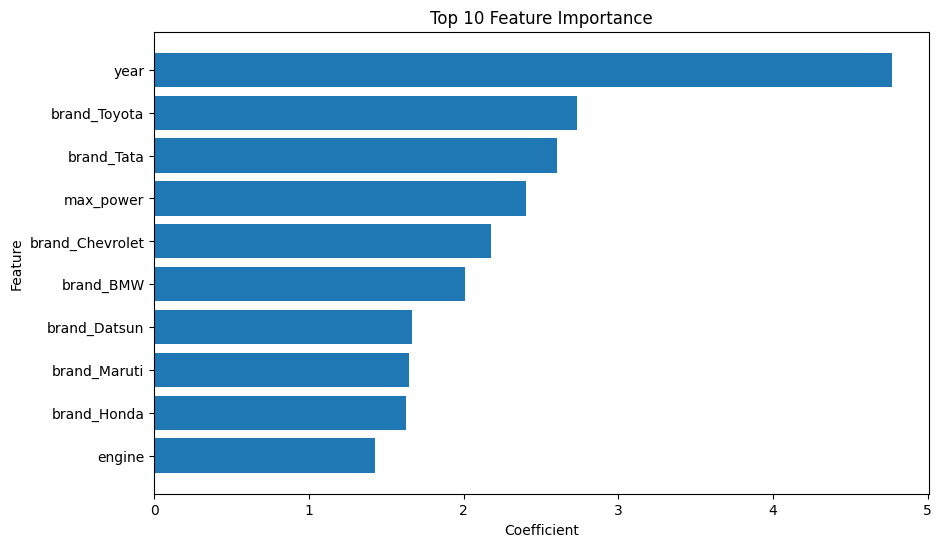

In [77]:
top_features = importance_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.show()

# Inference

Saving everything that will be needed for the deployment

In [78]:
#Saving everything needed for inference and deployment
inference = {
    "theta": best_model.theta,
    "columns": x_train.columns.tolist(),
    "price_bins": qcut_bins,

    #Imputation
    "mean_mileage": mean_mileage,
    "median_engine": median_engine,
    "median_max_power": median_max_power,
    "median_seats": median_seats,
    "mode_fuel": mode_fuel,
    "mode_seller_type": mode_seller_type,
    "mode_owner": mode_owner,

    #Scaling
    "scaler_year": scaler_year,
    "scaler_km": scaler_km,
    "scaler_mileage": scaler_mileage,
    "scaler_engine": scaler_engine,
    "scaler_power": scaler_power,
    "scaler_seats": scaler_seats}

joblib.dump(inference, "car_price_model3.pkl")

['car_price_model3.pkl']

# Report

In total, 6 models were tested using 5-fold cross-validation. One Normal Logistic Regression model with no penalty and five Ridge models with lambda values 0.005, 0.05, 0.5, 5 and 50. For all models, alpha was set to 0.0005 and max iterations to 5000. The models were compared using Accuracy, Macro F1 and Weighted F1. The best model was chosen based on the highest Mean Weighted F1 score from the 5-fold cross-validation, F1 beacuse it combines sensitivity and specificity so it is let us say pretty neutral.

The best model was Ridge with lambda 0.005, reaching mean Accuracy 0.6621, Macro F1 0.6222 and Weighted F1 0.6261. The final model reached Accuracy 0.6461 on the test set. I mean this result is not impressive, beacuse it is like a better guessing but... From the feature importance, year has the highest impact on the prediction, followed mostly by the car brand and max power.